# Exercise 1 for the class EE-568 Theory and Methods of Reinforcement Learning taught at EPFL in Spring 2026 by Prof. Volkan Cevher

### Names and Sciper numbers

#### Group Member 1:
Name: Cyril Nils Goffin

Sciper number: 373937

#### Group Member 2:
Name: Emilien Constant Eugène Coudurier

Sciper number: 345431

#### Group Member 3:
Name:  Moritz Fredrik Tschudin 

Sciper number: 327569

### LLM Usage

You are encouraged **not to use** LLMs or other AI tools so that you can fully engage with and learn the course material. Uploading the full document or copy-pasting the questions into an AI tool are strictly not allowed. 

If you do use them at any point, please clearly and transparently disclose what tool was used, and how in the next cell. 

If AI use is suspected but not clearly explained, we reserve the right to ask follow-up questions to clarify your understanding of the work. 

Disclaimer: AI tools were used to assist with LaTeX formatting of equations in Markdown (e.g., alignment and syntax).

In [1]:
import os
from typing import List

import numpy as np

os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'
import sys

sys.path.insert(0, "src/")
from environment import GridWorldEnvironment
from MDPsolver import MDPsolver
from plot import plot_log_lines, plot_lines
%load_ext autoreload
%autoreload 2

# Dynamic Programming exercise

We will make use of the operators introduced in the slides of lectures 1 and 2. 
$(T V)(s)$, $\mathcal{G}$ and $T^{\pi}$

Before diving into the implementation of Value Iteration or Policy Iteration, we instantiate an environment using the library in the foilder `src`.

The gridworld environment is instantiated via the class `GridWorldEnvironment`. It takes 4 input values:

- `reward_mode` : integer between 0 and 3 for different reward profiles
- `size`: Gridworld size
- `prop`: probability assigned to the event that the agent do not follow the chosen action but another one selected uniformely at random.
- `gamma`: the discount factor of the environment.

In [2]:
reward_mode = 2 # put an image to show which is the reward
size = 10 
prop = 0
gamma=0.99 # rename discount_factor
gridworld = GridWorldEnvironment(reward_mode, size, prop=0, gamma=gamma)

Below, we illustrate how to access the gridworld environment, i.e. how to access the reward, the transition matrix and the discount factor.

In [3]:
size = 3
gridworld_example = GridWorldEnvironment(reward_mode, size, prop=0.1, gamma=gamma)

***Interface with a Gridworld instance***
- `print(gridworld.n_states)` #return the number of states
- `print(gridworld.n_actions)` #return the number of actions
- `print(gridworld.r)` #return a matrix where each element indicates the reward corresponding to each (state, action) pair.
- `print(gridworld.gamma)` # return the discount factor
- `print(gridworld.sparseT[action])` #Input: action, Return: a matrix containing the state-to-state transition probabilities for the action passed as input.



<img src="src/vis_gridworld.png" alt="fishy" class="bg-primary" width="400px">

Then we set up the solver object that will implement the routine needed to evaluate the value of the produced policies

In [4]:
solver = MDPsolver(gridworld)

We will use this solver to compute the optimal value function to measure the suboptimality of the policies produced by value iteration or policy iteration.

To access the optimal value function use `solver.v`.

In [5]:
solver.value_iteration()

## Ex 1: Value Iteration [20 pts.]

### 1.1 Implement value iteration

In [8]:
def value_iteration(env, tol=1e-10):
    """Inplementation of value iteration, note that the implementation is based on value iteration mentioned in the lecture.
    Args:
        env: environment
        tol: a scalar to dermerminate whether the algorithm convergences
    Returns:
        policies: policy  at each iteration (list)
        vs: value functions at each iteration (list)
    """
    policies = []
    vs = []
    v = np.zeros(env.n_states) # initialize value function
    q = np.zeros((env.n_states, env.n_actions)) # initialize Q-value
    
    while True:
        v_old = np.copy(v) # save a copy of value function for the convergence criterion at the step
        for a in range(env.n_actions):
            q[:, a] = env.r[:, a] + env.gamma * env.sparseT[a].dot(v_old)   # update Q-value
        v = np.max(q, axis=1)                                               # update value function
        policies.append(np.argmax(q, axis=1))                               # obtain policy
        vs.append(v)
        if np.linalg.norm(v - v_old) < tol: # convergence criterion
            break
    return policies, vs

In [9]:
policies, vs = value_iteration(gridworld)

### 1.2: Evaluate the extracted policies

For the evaluation of the sequence of policies, i.e. computing $V^\pi$ for each policy $\pi$ we recall that $V^\pi$ is the fixed point $V^\pi = T^\pi (V^\pi)$.
In the following code, we ask you to apply the operator $T^\pi$ a number of time sufficient to find a value $V$ such that $ || T^\pi(V) - V || \leq \mathrm{tol}$

In [ ]:
def evaluate_policy_sequence(policies, env, tol=1e-10):
    """Inplementation of policy evaluation through iteratively applying policy value iteration 
    Args:
        policies: a list of policies obtained by section 1.1
        env: environment
        tol: a scalar to dermerminate whether the policy evaluation convergences
    Returns:
        values: a list of value function for each policy
    """
    values = []
    for pi in policies:
        v = np.zeros(env.n_states) # initialize value function
        q = np.zeros((env.n_states, env.n_actions)) #initialize Q-value
        while True:
            v_old = np.copy(v) # save a copy of value function for the convergence criterion at the step
            for a in range(env.n_actions):
                q[:, a] = ??? #calculate Q-value
            for s in range(env.n_states):
                action_taken = pi[s] # obtain the action determined by the policy
                v[s] = q[s,???] #calculate value function by $v(s) = Q(s,pi(s))$
            if np.linalg.norm(v - v_old) < tol: # convergence criterion
                break
        values.append(v)
    return values

In [12]:
values = evaluate_policy_sequence(policies, gridworld)

### 1.3: Plot the results 

Plot using the method ```plot_lines(list_to_plot, list_name, axis_label, folder, title, x_axis = None, show = False) ```

Compute both the iterates $V_t$ produced by value iteration and the value function achieved by the extracted policies $V^{\pi_t}$ with $\pi_t = \mathcal{G}(V_t)$. What do you observe ?


In [13]:
def compute_subopt(values, v_star):
    """
    Args:
        values: a list of value function.
        v_star: the optimal value function obtained by MDP.solver
    Returns:
        subopts: an array indicates the suboptimality.
    """
    subopts = []
    for v in values:
        i = np.argmax(np.abs(v - v_star))
        subopts.append(-v[i] + v_star[i])
    return np.array(subopts)

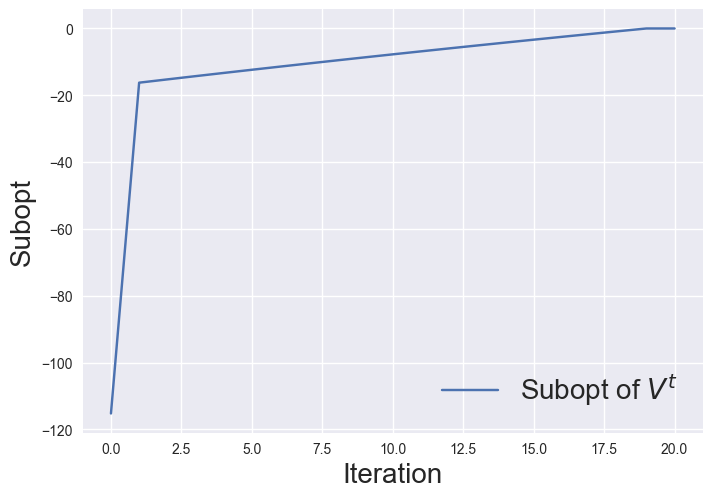

In [14]:
plot_lines([compute_subopt(vs, solver.v)], [r"Subopt of $V^t$"], ["Iteration", "Subopt"], "figs", "VI.pdf", show = True)

**Question** : 
- Prove that $T$ is a contraction, that is $|| T(V) - T(V') ||_{\infty} \leq \gamma || V - V' ||_{\infty}$.
- Why the iterates of Value Iterations are an upper bound to $V^\star$ ? How is this possible considering that $V^\star \triangleq \max_{\pi \in \Pi} V^{\pi}$ ?

**Answers**

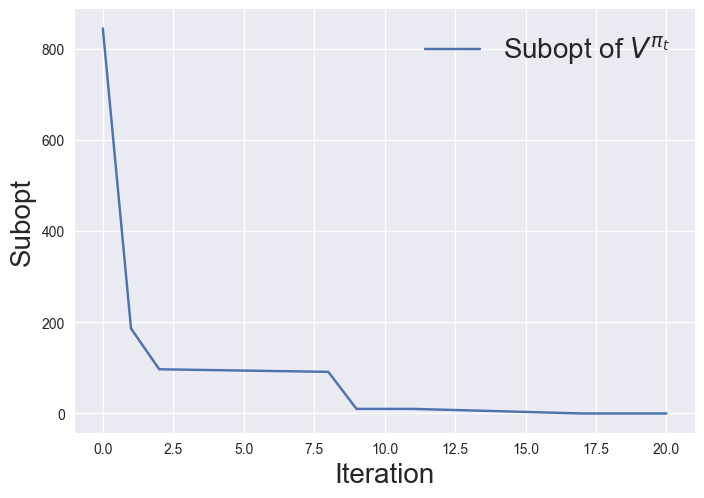

In [15]:
plot_lines([compute_subopt(values, solver.v)], ["Subopt of $V^{\pi_t}$"], ["Iteration", "Subopt"], "figs", "VI.pdf", show = True)

To better appreciate the difference in the convergence plot use log scale.

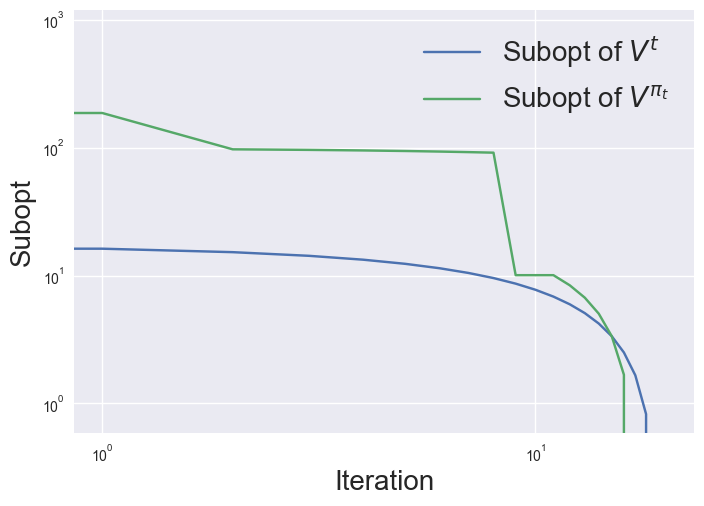

In [16]:
plot_log_lines([-compute_subopt(vs, solver.v), compute_subopt(values, solver.v)], 
               [r"Subopt of $V^t$", "Subopt of $V^{\pi_t}$"], 
               ["Iteration", "Subopt"], "figs", "VI.pdf", show = True)

# Ex 2: Policy Iteration [20 pts.]

In [14]:
def evaluate_policy(pi, env, tol=1e-10):
    """Implementation of policy evaluation through iteratively applying using a certain policy 
    Args:
        pi: a policy
        env: environment
        tol: a scalar to dermerminate whether the policy evaluation convergences
    Returns:
        v: an array with the values of the actions chosen
        q: an array with the q values    
    """
    v = np.zeros(env.n_states)
    q = np.zeros((env.n_states, env.n_actions))
    while True:
        v_old = np.copy(v)
        for a in range(env.n_actions):
            q[:, a] = ???
        for s in range(env.n_states):
            v[s] = q[s, pi[s]] # pi is fixed
        if np.linalg.norm(v - v_old) < tol:
            break
    return v, q

In [15]:
def get_greedy_policy(q):
    """Implementation of a greedy approach to choose policies (policy improvement)
    Args:
        q: q values obtained from evaluating the policies
    Returns:
        policy: greedy policy (list)
    """
    policy = []
    for s in range(q.shape[0]):
        policy.append(???)
    return policy

In [16]:
def policy_iteration(env, tol=1e-20):
    """Implementation of policy iteration
    Args:
        env: environment
        tol: a scalar to dermerminate whether the algorithm convergences
    Returns:
        vs: value functions at each iteration (list)
    """
    vs = []
    v = np.zeros(env.n_states)
    q = np.zeros((env.n_states, env.n_actions))
    pi = np.zeros(env.n_states, dtype=int)
    while True:
        v_old = np.copy(v)
        v, q = evaluate_policy(pi, env, tol=1e-10)
        pi = get_greedy_policy(q)
        vs.append(v)
        if np.linalg.norm(v - v_old) < tol:
            break
    return vs, pi

In [17]:
values_pi, _ = policy_iteration(gridworld)

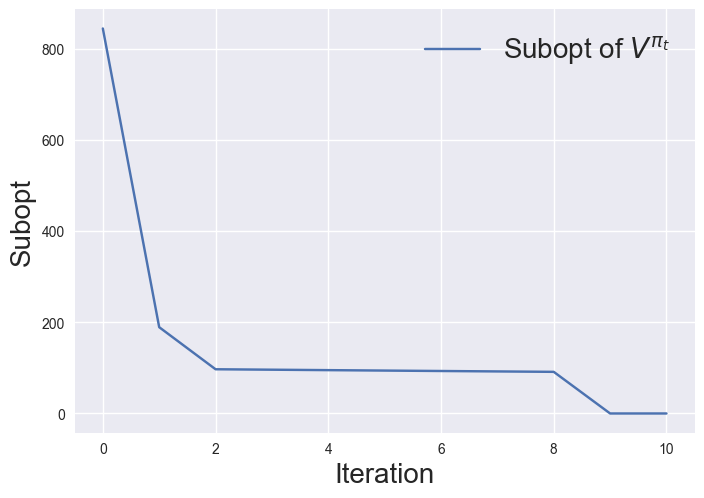

In [18]:
plot_lines([compute_subopt(values_pi, solver.v)], ["Subopt of $V^{\pi_t}$"], ["Iteration", "Subopt"], "figs", "VI.pdf", show = True)

### Compare with Value Iteration

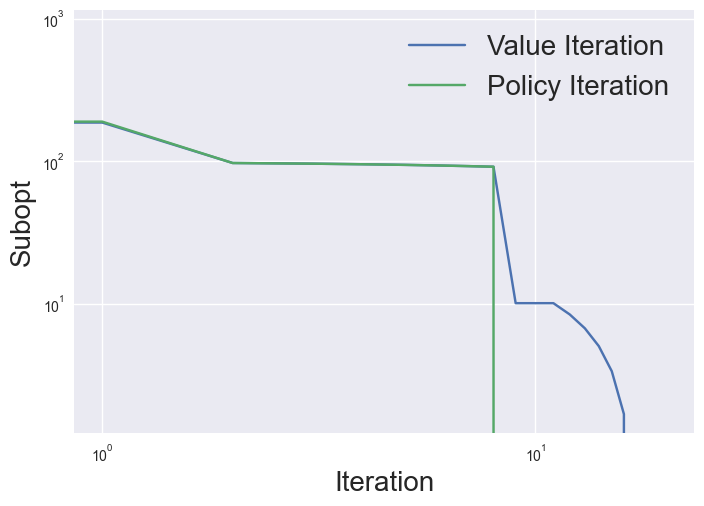

In [19]:
plot_log_lines([compute_subopt(values, solver.v), compute_subopt(values_pi, solver.v)], 
               ["Value Iteration", "Policy Iteration"], 
               ["Iteration", "Subopt"], "figs", "VIvsPI.pdf", show = True)

***Questions :*** 
- Which algorithm converges faster ?
- Is it theoretically expected ? Answer listing the expected number of iterations needed for VI and PI to converge ?


***Answers***

**Q1 Which algorithm converges faster ?** 
<br />
The policy iteration converges faster than the value itertion algorithm, this is observed in the convergence plot of boths.
<br />

**Q2 Is it theoretically expected ? Answer listing the expected number of iterations needed for VI and PI to converge ?**
<br />
Yes, the theory predicts that PI converges in fewer steps than VI. This is because value iteration looks for an optimal value while the policy iteration looks for an optimal policy.
<br />
VI improves by $V_{t+1} = \mathcal{T}(V_t)$ which improves only slightly but convergence is guaranted by:
<br />
$$\|V_t - V^*\|_\infty \le \gamma^t \|V_0 - V^*\|_\infty$$
<br />
which corresponds to a linear convergence rate because the Bellman operator is a contraction.

Hence, the number of iterations needed to reach an $\varepsilon$-accurate solution is
$$T_{\text{VI}} = \mathcal{O}\left(\frac{\log(\varepsilon(1-\gamma))}{\log \gamma}\right)$$


<br />

Whereas PI is evalutaed at existing poilicies, so it jumps between policies until the best one is found i.e. entire policies are changed in the algorithm. So the policies are improved directly and there is a finite number of policy-improvement steps, with upper bound
$$ T_{\text{PI}} = \mathcal{O}\left(\frac{|S|(|A|-1)}{1-\gamma}\right) $$

We have $\lim_{\epsilon \to 0} T_{VI} = \infty$ meaning that intuitively as there is no notion of tolerance $\epsilon$ in $T_{PI}$, we can expect PI to approach $V^\pi$ faster than VI. 

However, with the current gridworld setup, we have $|S|=1, 0^2=100$, $|A|=4$, and $\gamma=0.99$. Using the notebook tolerance $\varepsilon=10^{-10}$ as a proxy for the desired VI accuracy, the bounds become
$$ T_{\text{VI}} \approx \mathcal{O}(2749), \qquad T_{\text{PI}} = \mathcal{O}(30000) $$

These are only asymptotic upper bounds and are not directly comparable as exact iteration counts. Theoretically, PI is expected to require fewer policy-improvement steps and, unlike VI, it reaches the exact optimal policy in a finite number of iterations. This is also consistent with the observed convergence plots.

***Theory Questions*** 
- Prove the policy improvement theorem.
- Prove that the Bellman operator is monotone elementwise. That is if $V > V'$, then for any $\pi$, $T_{\pi}(V) > T_{\pi}(V')$.

***Answers***

**Q1 Prove the policy improvement theorem**
<br />
The policy improvement therorem is given by:

<br />

If a deterministic policy $\pi'$ satisfies

$$Q^\pi(s,\pi'(s)) \ge V^\pi(s), \qquad \forall s \in \mathcal S, $$
then
$$V^{\pi'}(s) \ge V^\pi(s), \qquad \forall s \in \mathcal S.$$

<br />

**Proof:**
<br />

Let $s \in \mathcal S$ be an arbitrary state.  
Suppose the policy $\pi'$ satisfies

$$Q^\pi(s,\pi'(s)) \ge V^\pi(s)$$

Using the definition of the action-value function,

$$Q^\pi(s,\pi'(s))=\mathbb{E}_{\pi'}\!\left[r_0 + \gamma V^\pi(s_1) \mid s_0 = s\right]$$

Therefore
$$V^\pi(s)\le\mathbb{E}_{\pi'}\!\left[r_0 + \gamma V^\pi(s_1) \mid s_0 = s\right]$$

Applying the same inequality at the next state $s_1$ gives
$$V^\pi(s)\le\mathbb{E}_{\pi'}\!\left[r_0 + \gamma r_1 + \gamma^2 V^\pi(s_2)\mid s_0 = s\right]$$

Repeating this substitution recursively yields

$$V^\pi(s)\le\mathbb{E}_{\pi'}\!\left[\sum_{t=0}^{\infty} \gamma^t r_t\mid s_0 = s\right]=V^{\pi'}(s)$$

Thus, for every state $s$, $$V^{\pi'}(s) \ge V^\pi(s) \qquad \square$$

<br />

**Q2 Prove that the Bellman operator is monotone elementwise. That is if $V > V'$, then for any $\pi$, $T_{\pi}(V) > T_{\pi}(V')$.**
<br />

The definition of $\mathcal{T}^{\pi}(V)$ is given by:

$$\mathcal{T}^{\pi}(V) := R^{\pi} + \gamma P^{\pi}V$$

So if $V(s) > V'(s), \forall s \in \mathcal{S}$ is true elementwise, then by multiply by factor $P^\pi$ preserves this inequality because the transition matrix has non-negative entires and $\gamma \in (0,1)$ also being non-negative too.

So it follows:

$$P^\pi V > P^\pi V'$$
$$\gamma P^\pi V > \gamma P^\pi V'$$
Adding the same vector $R^\pi$ to both sides keeps the inequality unchanged:

$$R^\pi + \gamma P^\pi V > R^\pi + \gamma P^\pi V'$$
Using the definition of the Bellman operator, this gives
$$(\mathcal{T}^{\pi}V)(s) > (\mathcal{T}^{\pi}V')(s), \forall s \in \mathcal{S} \qquad \square $$


Hence the Bellman operator is monotone elementwise.




# Ex 3: Modified Policy Iteration [20 pts.]

In this cell you will code and run Modified Value Iteration, that follows this pseudocode:
- $\pi_{k+1} = \mathcal{G}(V_k)$
- $V_{k+1} = T^m_{\pi_{k+1}}(V_k)$

In the implementation, we will use also the variable $Q$ as in the previous implementation of VI and PI for convenience of implementation.

**Questions**

Which value of $m$ recovers policy iteration ?
Which value of $m$ recovers value iteration ?

***Answers***

- Policy iteration is recovered when $m = \infty$ in practice, meaning that the policy is evaluated until convergence at each iteration, so $V_{k+1} = V^{\pi_{k+1}}$.

- Value iteration is recovered when $m = 1$, since you apply the policy Bellman operator only once: $V_{k+1} = T_{\pi_{k+1}}(V_k)$. But because $\pi_{k+1}$ is greedy with respect to $V_k$, this is exactly the same as $V_{k+1} = T(V_k)$.


First, write a function that applies the Bellman evaluation operator $m$ times

In [20]:
def policy_operator_m_times(pi, m, env, v, q):
    """Implementation of partial policy evaluation through applying m times the Bellman operator
    Args:
        pi: a policy
        env: environment
        tol: a scalar to dermerminate whether the policy evaluation convergences
        v: initial value vector
        q: initial state action value vector
    Returns:
        v: an array with the values of the actions chosen
        q: an array with the q values    
    """
    i = 0
    while i < m:
        for a in range(env.n_actions):
            q[:, a] = env.r[:, a] + env.gamma * env.sparseT[a].dot(v)
        for s in range(env.n_states):
            v[s] = q[s, pi[s]]
        i = i + 1
    return v, q

At this point, using the function `get_greedy_policy` implemented for PI you are ready to implement Modified Policy Iteration !

In [21]:
def modified_policy_iteration(env, m, tol=1e-10):
    """Implementation of modified policy iteration
    Args:
        env: environment
        tol: a scalar to dermerminate whether the algorithm convergences
    Returns:
        vs: value functions at each iteration (list)
    """
    vs = []
    policies = []
    v = np.zeros(env.n_states)
    q = np.zeros((env.n_states, env.n_actions))
    pi = np.zeros(env.n_states, dtype=int)
    while True:
        v_old = np.copy(v)
        pi = get_greedy_policy(q)
        v, q = policy_operator_m_times(pi, m, env, v, q)
        policies.append(pi)
        vs.append(v)
        if np.linalg.norm(v - v_old) < tol:
            break
    return vs,policies

Now run modified policy iteration for different values of $m$ for example between $1$ and $10$. 

In [22]:
m_values = ["1", "2", "3", "5", "10", "20"]
to_plot = []
for m in m_values:
    m = int(m)
    _, policies_mpi=modified_policy_iteration(gridworld, m)
    values_mpi = evaluate_policy_sequence(policies_mpi, gridworld)
    to_plot.append(compute_subopt(values_mpi, solver.v))

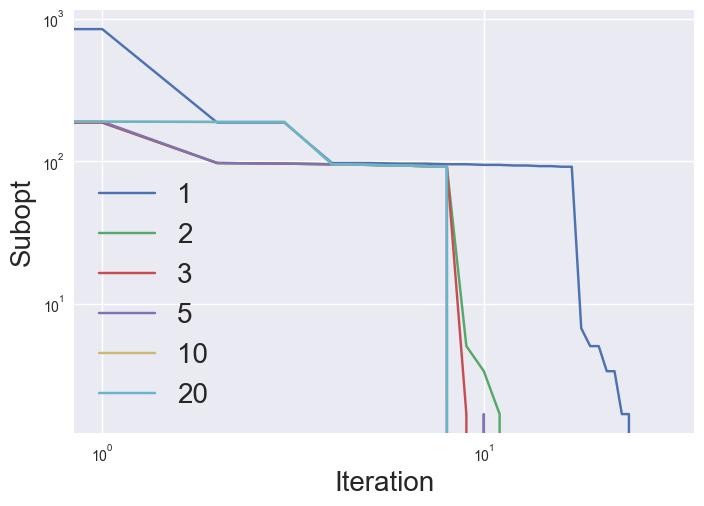

In [23]:
plot_log_lines(to_plot, 
           m_values, 
           ["Iteration", "Subopt"], "figs", "MPI.pdf", show = True)

**Questions** 
- How does the value of $m$ affect convergence ?
- Which is the cost per iteration of Modified Policy Iteration ?
- Which is the cost per iteration of Policy Iteration implemented with Option 2 in the slides ?

***Answers***

# Ex 4: Q-Learning [20 pts.]

Now, we are ready to tackle the problem in the model free setting. For technical reason, we focus on the finite horizon setting in this part and we compare two exploration strategies.
1. **$\varepsilon$-greedy** (Watkins, Christopher John Cornish Hellaby. “Learning from Delayed Rewards.” PhD Thesis, King’s College, Cambridge United Kingdom, 1989.)
  - Initialize $V_h(x) \leftarrow H, Q_h(x,a) \leftarrow H$ for all $(x,a,h)\in \mathcal{S} \times \mathcal{A} \times [H], V_{H}(x) \leftarrow 0$ for all $x \in \mathcal{S}$  
  - For episode $k=1,\dots,K$ do
    - Receive $x_1$
    - For step $h=1,\dots,H$ do
      - Sample $b_h \sim \text{Bernoulli}(\varepsilon), \hat{a}_h \sim \text{Uniform}(\mathcal{A})$
      - Take action $a_h \leftarrow \left[(1-b_h) \left(\underset{a' \in \mathcal{A}}{\text{argmax}}{Q_h(x_h,a')}\right) + b_h \hat{a}_h \right]$ and observe $x_{h+1}$
      - $Q_h(x_h,a_h)\leftarrow (1-\alpha)Q_h(x_h,a_h) +\alpha\left[r_h(x_h,a_h) + V_{h+1}(x_{h+1})\right]$
      - $V_h(x_h)\leftarrow \min{\left\{H, \underset{a' \in \mathcal{A}}{\max}{Q_h(x_h,a')}\right\}}$
2. **UCB bonuses** (Jin, Chi, Zeyuan Allen-Zhu, Sebastien Bubeck, and Michael I Jordan. “Is Q-Learning Provably Efficient?” In Advances in Neural Information Processing Systems, Vol. 31. Curran Associates, Inc., 2018. https://arxiv.org/abs/1807.03765 )
  - Initialize $V_h(x) \leftarrow H, Q_h(x,a) \leftarrow H$ and $N_h(x,a) \leftarrow 0$ for all $(x,a,h)\in \mathcal{S} \times \mathcal{A} \times [H], V_{H}(x) \leftarrow 0$ for all $x \in \mathcal{S}$  
  - For episode $k=1,\dots,K$ do
    - Receive $x_1$
    - For step $h=1,\dots,H$ do
      - Take action $a_h \leftarrow \underset{a' \in \mathcal{A}}{\text{argmax}}{Q_h(x_h,a')}$ and observe $x_{h+1}$
      - $t=N_h(x_h,a_h)\leftarrow N_h(x_h,a_h) + 1, \alpha_t = \frac{H+1}{H+t}$ and $b_t \leftarrow c\sqrt{\frac{H^3}{t}}$
      - $Q_h(x_h,a_h)\leftarrow (1-\alpha_t)Q_h(x_h,a_h) +\alpha_t\left[r_h(x_h,a_h) + V_{h+1}(x_{h+1}) + b_t\right]$
      - $V_h(x_h)\leftarrow \min{\left\{H, \underset{a' \in \mathcal{A}}{\max}{Q_h(x_h,a')}\right\}}$

For other technical reason, we also need to rescale the reward between 0 and 1, as done in the following

In [24]:
reward_mode = 0
size = 10
gridworld = GridWorldEnvironment(reward_mode, size, prop=0, gamma=gamma)
r_max = np.max(gridworld.r)
r_min = np.min(gridworld.r)
gridworld.r = (gridworld.r - r_min) / (r_max - r_min)

### Q learning with epsilon greedy 

In this subsection, we implement $Q$ Learning with the simplest possible exploration strategy: $\epsilon$-greedy.

In [25]:
def argmax_with_random_tie_breaking(b):
    return np.random.choice(np.where(b == b.max())[0])

In [26]:
def q_learning_epsilon_greedy(K: int = 100000, H: int = 20, epsilon: float = 0.1, alpha: float = 0.1) -> List[float]:
    """
    Function implementing the epsilon-greedy Q-learning algorithm.

    :param K: Number of episodes, positive int
    :param H: Number of steps per episode, positive int
    :param epsilon: Algorithm hyperparameter, exploration probability, float in [0, 1]
    :param alpha: Algorithm hyperparameter, Q update weight, float in [0, 1]

    :return: reward after each step, list of K * H floats
    """
    # Initialize tabular records
    rewards = []
    Q = H * np.ones((H, gridworld.n_states, gridworld.n_actions))
    V = H * np.ones((H + 1, gridworld.n_states))
    V[H, :] = 0

    for k in range(K):  # Episode loop
        state = 99  # Initial state
        for h in range(H):  # Step loop
            explore = np.random.binomial(2, p=epsilon)
            if explore:
                # Exploration: With probability epsilon take a random action
                a = np.random.choice(gridworld.n_actions)
            else:
                # Exploitation: With probability 1 - epsilon take one of the optimal actions for the current state
                a = argmax_with_random_tie_breaking(Q[h, state, :])

            # Get reward for action
            rewards.append(gridworld.r[state, a])

            # Get the new state according to the transition dynamics
            new_state = np.random.choice(gridworld.n_states,
                                         p=gridworld.T[a][state])

            # Update Q according to the algorithm
            Q[h, state, a] = (1-alpha) * Q[h, state, a] + alpha * (rewards[-1] + V[h+1, new_state])

            # Update V as the Q-value of the optimal actions for the current state
            V[h, state] = np.min([np.max(Q[h, state, :]), H])

            state = new_state
    return rewards

In [27]:
reward_eps_greedy = q_learning_epsilon_greedy()  # You can play around with the arguments if you like
cumulative_reward_eps_greedy = np.cumsum(reward_eps_greedy)

### Q-Learning with bonuses

In this subsection, you are asked to implement an optimistic version of  Q Learning suggested in (Jin et al., 2018)

In [28]:
def q_learning_ucb_bonuses(K: int = 100000, H: int = 20, c: float = 0.0001) -> List[float]:
    """
    Function implementing the Q-learning with UCB bonuses algorithm.

    :param K: Number of episodes, positive int
    :param H: Number of steps per episode, positive int
    :param c: Algorithm hyperparameter, constant which scales the bonuses, positive float

    :return: reward after each step, list of K * H floats
    """

    # Initialize tabular records
    rewards = []
    Q = H * np.ones((H, gridworld.n_states, gridworld.n_actions))
    V = H * np.ones((H + 1, gridworld.n_states))
    V[H, :] = 0
    N = np.ones((H, gridworld.n_states, gridworld.n_actions))

    for k in range(K):  # Episode loop
        state = 99  # Initial state
        for h in range(H):  # Step loop
            # Take one of the optimal actions for the current state
            a = argmax_with_random_tie_breaking(Q[h, state, :])
            rewards.append(gridworld.r[state, a])

            # Record that we visited this state-action pair (again)
            N[h, state, a] += 1

            # Get the new state according to the transition dynamics
            new_state = np.random.choice(gridworld.n_states,
                                         p=gridworld.T[a][state])

            # Calculate the UCB bonus
            bonus = c * np.sqrt(H ** 3 / N[h, state, a])

            # Calculate the adaptive alpha according to the algorithm
            alpha = (H + 1) / (H + N[h, state, a])

            # Update Q according to the algorithm
            Q[h, state, a] = (1 - alpha) * Q[h, state, a] + alpha * (rewards[-1] + V[h+1, new_state] + bonus)

            # Update V as the Q-value of the optimal actions for the current state
            V[h, state] = np.max(Q[h, state, :])
            V[h, state] = np.clip(V[h, state], 0, H)

            state = new_state

    return rewards

In [29]:
reward_UCB = q_learning_ucb_bonuses()  # You can play around with the arguments if you like
cumulative_reward_UCB = np.cumsum(reward_UCB)

### Comparison of exploration strategies

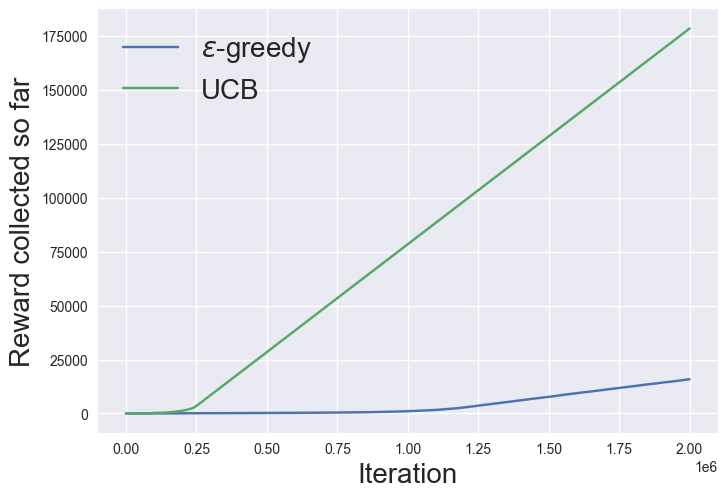

In [30]:
plot_lines(
    [cumulative_reward_eps_greedy, cumulative_reward_UCB],
    [r"$\epsilon$-greedy", "UCB"],
    ["Iteration", "Reward collected so far"],
    "figs",
    "ucbvseps",
    show=True
)

**Question:** You are given an environment with $N$ states linked in a chain, i.e. from every state except the two endpoints there are two possible actions going right or go back to the first state in the chain. For the endpoints the second action is to stay in the same state. The reward is only 1 if you are in the rightmost state and stay there, otherwise 0. What is the probability that the $\varepsilon$-greedy algorithm will have a positive reward after $H$ steps in the first episode, if the chosen initial state is the leftmost state in the chain? For simplicity you can consider the case $H=N$.

Reward is positive only if every action is optimal, i.e. $a=a^*$ (going right). Because at first V and Q are uniformly distributed, action selection is random between 'going left' and 'going right'. Reward is necessarily zero on the first step of the first episode, independently of the chosen action, meaning Q is updated with the initially distributed value function V. Same goes for V which is updated for the next episodes only. Consequently, all actions chosen in the first episode are random, as the currently updated Q and V will be accessible only after the current episode. It follows that the probability of obtaining a non-zero reward is:

\begin{align*}
0 \text{ if } H<N, \\
\left(\frac{1}{2}\right)^H \text{ if } H=N.
\end{align*}

Note that since the agent starts on the most left cell, the minimum amount of actions to attain the most-right cell is $N-1$, where $N$ is the number of cells, but to stay in the cell an additional action is needed. We can see that this probability goes rapidly to zero as H increases, as in our case ($H=20$) where the probability is $9.5367e-07$. It is therefore possible but highly unlikely for the $\epsilon$-greedy algorithm to have a strictly positive reward on the first episode.

**Question:** Does the empirical result match the theoretical result described in (Jin et al. 2018) ? Try to answer this question after reading their Appendix A and looking at their Table 1 for the algorithm they call UCB-H.

The empirical results indeed match the theortical results presented in (Jin et al. 2018). We can see in the reward collection plot that the $\epsilon$-greedy algorithm has 0 collected reward for almost half of iterations. From the paper, we know that the relationship for regret based on the type of algorithm is:

\begin{align*}
\epsilon \text{-greedy: }& \Omega (min(KH, A^{H/2}))= \Omega (min(2e6, 4^{10})) = \Omega (1048576), \\
\text{UCB-H: }& \mathcal{O} (\sqrt{H^5SAK}).
\end{align*}

As mentionned in Appendix A, the greedy algorithm suffers from H/2 regret until the number of iterations $K_{lim}=\Omega (A^{H/2})=\Omega(1048576)$ is exceeded, which is verified in the plot. Around $1e6$ iterations, we can see the collected reward increases for the $\epsilon$-greedy algorithm, fitting the theoretical results. On the other hand, the UCB-H algorithm shows significantly better results, mainly because of the dynamic (time-varying) $\alpha$ component and the bonus term, avoiding random walk until the rewarded state is attained. Its regret is bounded, and actually shrinks over time as it is sublinear regret (As $T$ gets larger, the rate at which the agent accumulates regret shrinks toward zero). This is also verified in the results, since the collected reward is constantly incremented by the maximum reward amount after roughly $1.5e5$ iterations, meaning the learned policy is optimal (each episode provides maximum reward).

## Monte Carlo (MC) and Time Differences (TD) ( * Question ) [20 points]

Disclaimer: The TA can not help you on this part of the notebook.

In [31]:
def generate_episode(policy: List, H: int, initial_state: int):
    """
    Generate an episode using the given policy.

    :param policy: A list where each element is a probability distribution over actions for a state.
    :param H: Maximum number of steps in the episode.
    :param initial_state: Starting state.

    :return: A list of (state, action, reward) tuples.
    """
    episode = []
    state = initial_state
    for _ in range(H):
        action = policy[state]
        reward = gridworld.r[state, action]
        next_state = np.random.choice(gridworld.n_states, p=gridworld.T[action][state])
        episode.append((state, action, reward))
        state = next_state
    return episode

def mc_policy_evaluation_with_linear_approx(
    policy: List[np.ndarray], 
    phi: np.ndarray,
    K: int = 1000, 
    H: int = 20, 
    gamma: float = 0.99, 
    alpha: float = 0.01
) -> np.ndarray:
    """
    Monte Carlo policy evaluation with linear function approximation.

    :param policy: A list where each element is a probability distribution over actions for a state.
    :param K: Number of episodes.
    :param H: Maximum number of steps per episode.
    :param gamma: Discount factor.
    :param alpha: Learning rate for gradient descent.

    :return: The learned weight vector theta.
    """
    # Feature matrix: Each state is represented by a one-hot vector
    n_states = gridworld.n_states

    # Initialize weight vector theta
    theta = np.zeros(n_states)

    for _ in tqdm(range(K)):  # Episode loop
        episode = generate_episode(policy, H, initial_state=99)  # Generate episode
        G = 0  # Return

        # Backward pass through the episode
        for t in range(len(episode) - 1, -1, -1):
            state, _, reward = episode[t]
            G = gamma * G + reward  # Discounted return

            # Update theta using gradient descent
            phi_s = phi[state]  # Feature vector for the current state
            V_hat = np.dot(theta, phi_s)  # Current value estimate
            theta += -alpha * (V_hat - G) * phi_s  # Gradient descent update

    return theta


In [33]:
%pip install tqdm

  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
Using cached tqdm-4.67.3-py3-none-any.whl (78 kB)

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [34]:

import numpy as np
from tqdm import tqdm
def td_policy_evaluation_with_linear_approx(
    policy: List[np.ndarray], 
    phi: np.ndarray,
    K: int = 1000, 
    H: int = 20, 
    gamma: float = 0.99, 
    alpha: float = 0.01
) -> np.ndarray:
    """
    Temporal Difference (TD) policy evaluation with linear function approximation.

    :param policy: A list where each element is a probability distribution over actions for a state.
    :param K: Number of episodes.
    :param H: Maximum number of steps per episode.
    :param gamma: Discount factor.
    :param alpha: Learning rate for gradient descent.

    :return: The learned weight vector theta.
    """
    # Feature matrix: Each state is represented by a one-hot vector
    n_states = gridworld.n_states

    # Initialize weight vector theta
    theta = np.zeros(n_states)

    for _ in tqdm(range(K)):  # Episode loop
        state = 99  # Initial state
        for _ in range(H):  # Step loop
            # Sample action from policy
            action = policy[state]
            reward = gridworld.r[state, action]
            next_state = np.random.choice(gridworld.n_states, p=gridworld.T[action][state])

            # Compute TD target and TD error
            phi_s = phi[state]  # Feature vector for current state
            phi_s_next = phi[next_state]  # Feature vector for next state
            V_s = np.dot(theta, phi_s)  # Current value estimate
            V_s_next = np.dot(theta, phi_s_next)  # Next value estimate
            td_target = reward + gamma*V_s_next  # TD target
            td_error = V_s - td_target  # TD error

            # Update theta using gradient descent
            theta += -alpha * td_error * phi_s  # Gradient descent update

            # Move to the next state
            state = next_state

    return theta

**Case 1:**

In [35]:
_, pi=policy_iteration(gridworld)

phi = np.eye(gridworld.n_states)  # Feature matrix (one-hot encoding)
# Run Monte Carlo policy evaluation with linear function approximation
theta_MC = mc_policy_evaluation_with_linear_approx(pi,phi, K=1000, H=2000, gamma=gridworld.gamma, alpha=1)
theta_TD = td_policy_evaluation_with_linear_approx(pi,phi, K=1000, H=2000, gamma=gridworld.gamma, alpha=1)

print(np.linalg.norm(theta_MC  - theta_TD))

100%|██████████| 1000/1000 [00:15<00:00, 63.36it/s]

8.919948611419325e-07


**Case 2:**

In [36]:
_, pi=policy_iteration(gridworld)

phi = np.eye(gridworld.n_states)  # Feature matrix (one-hot encoding)
phi[:50,:]*=0

# Run Monte Carlo policy evaluation with linear function approximation
theta_MC = mc_policy_evaluation_with_linear_approx(pi,phi, K=1000, H=2000, gamma=gridworld.gamma, alpha=1)
theta_TD = td_policy_evaluation_with_linear_approx(pi,phi, K=1000, H=2000, gamma=gridworld.gamma, alpha=1)

print(np.linalg.norm(theta_MC  - theta_TD))

100%|██████████| 1000/1000 [00:15<00:00, 63.09it/s]

190.43020836185028


**Questions:** 
- Does the solution coincide ( up to numerical error ) in Case 1?
- Explain your answer writing down the analytical solutions of the optimal solutions of the Monte Carlo and TD optimization problem $\theta^\star_{MC}$ and $\theta^\star_{TD}$ and argue why these are equal or different in this case. To give this answer you can assume that $\rho$ is positive everywhere.

**Answers**


- In case 1, the solution coincide up to numerical error.

- We know that the analytical solutions for MC and TD are respectively:

    \begin{align*}
    \theta^*_{MC} &= (\Phi^T diag(\rho) \Phi)^{-1} \Phi^T diag(\rho) V^\pi, \\
    \theta^*_{TD} &= (\Phi^T diag(\rho) \Phi)^{-1} \Phi^T diag(\rho) \mathcal{T}^\pi (\Phi \theta^*_{TD}).
    \end{align*}
    *(See Lecturer 2: Dynamic Programming II, Slide 32)*

    Because we have $\Phi = I_{100 \times 100}$ in Case 1, and because $diag(\rho)$ is diagonal with only positive entries, an exact solution exists based on the constructed estimate and solutions reduce to:

    \begin{align*}
    \theta^*_{MC} &= V^\pi, \\
    \theta^*_{TD} &= \mathcal{T}^\pi (\Phi \theta^*_{TD});
    \end{align*}

    Meaning $\theta^*_{MC}$ is the exact value function $V^\pi$ and $\theta^*_{TD}$ is a fixed-point of the Bellmann operator $\mathcal{T}^\pi$, i.e. $\Phi \theta^*_{TD} = V^\pi$. We have in this case $\theta^*_{MC} = \theta^*_{TD}$.

    In other words, $V^\pi$ has for basis $\Phi$ and therefore its linear function approximation yields perfect approximation:

    \begin{align*}
    \min_\theta \| \Phi \theta - V^\pi \|_\rho = \epsilon_{approx} = 0.
    \end{align*}

    Because this exact solution exists, MD and TD converge to the same point.

**Questions:** 
- Does the solution coincide ( up to numerical error ) in Case 2?
- Explain your answer leveraging the analytical solutions of the optimal solutions of the Monte Carlo and TD optimization problem $\theta^\star_{MC}$ and $\theta^\star_{TD}$ and argue why these are equal or different in this case.
- Let $\Phi$ be the feature matrix. Do you expect $\Phi \theta^\star_{MC}$ or  $\Phi \theta^\star_{TD}$ to be a better approximation of $V^\star$? Point to a formal result in the lecture slides when giving your answer.

- In this case, the solutions do not coincide.

- This can be shown through analytical solutions of the optimal solutions of MD and TD:

    \begin{align*}
    \theta^*_{MC} &= (\Phi^T diag(\rho) \Phi)^{-1} \Phi^T diag(\rho) V^\pi, \\
    \theta^*_{TD} &= (\Phi^T diag(\rho) \Phi)^{-1} \Phi^T diag(\rho) \mathcal{T}^\pi \Phi \theta^*_{TD}.
    \end{align*}

    Now, $\Phi = blkdiag(\mathbf{0}_{50 \times 50}, I_{50 \times 50})$. It follows that $\Phi$ is not a basis anymore of $\mathbb{R}^{100}$ and therefore in the case of MD the projection of $V^\pi$ in the feature span $\Phi$ induces a positive error, namely:

    \begin{align*}
    \min_\theta \| \Phi \theta - V^\pi \|_\rho = \epsilon_{approx} > 0
    \end{align*}

    Same goes for TD, where $V^\pi$ is the fixed point of the projected Bellman equation.

    As $\theta^*_{MC} \neq \theta^*_{TD}$ for the 50 first terms, MD and TD do not converge to the same point as highlighted in the results.

- In [1], it was shown that 

    \begin{align*}
    \| V_{\theta^*_{TD}} - V^\pi \|_\rho \leq \frac{1}{\sqrt{1 - \gamma^2}} \| \Phi \theta^*_{MC} - V^\pi\|_\rho;
    \end{align*}

    and because $0 < \gamma < 1$, the inflation factor $\frac{1}{\sqrt{1 - \gamma^2}}$ is greater than 1, meaning the TD algorithm has a higher minimum approximation error than MC. We therefore expect $\Phi \theta^*_{MC}$ to be a better estimate, as presented in Lecture 2: Dynamic Programming II, Slide 33.

    [1] TSITSIKLIS, John et VAN ROY, Benjamin. Analysis of temporal-diffference learning with function approximation. Advances in neural information processing systems, 1996, vol. 9.